In [99]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer , OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import mlflow

In [100]:
train = pd.read_csv("datasets/adult.csv")


## EDA

In [101]:
# Shape and types
print(train.shape)
train.info()

(32561, 15)
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [102]:
train.head(20)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [103]:
train.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [104]:
# Missing values: dataset uses "?" as placeholder
df = train.replace("?", np.nan)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print()
print((missing / len(df) * 100).round(2).astype(str) + " %")

occupation        1843
workclass         1836
native.country     583
dtype: int64

occupation        5.66 %
workclass         5.64 %
native.country    1.79 %
dtype: str


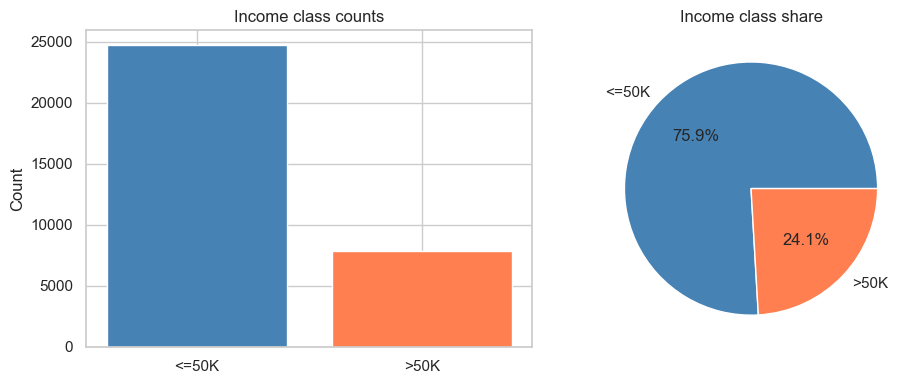

In [105]:
# Target distribution
counts = df["income"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(counts.index, counts.values, color=["steelblue", "coral"])
axes[0].set_title("Income class counts")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=["steelblue", "coral"])
axes[1].set_title("Income class share")

plt.tight_layout()
plt.show()

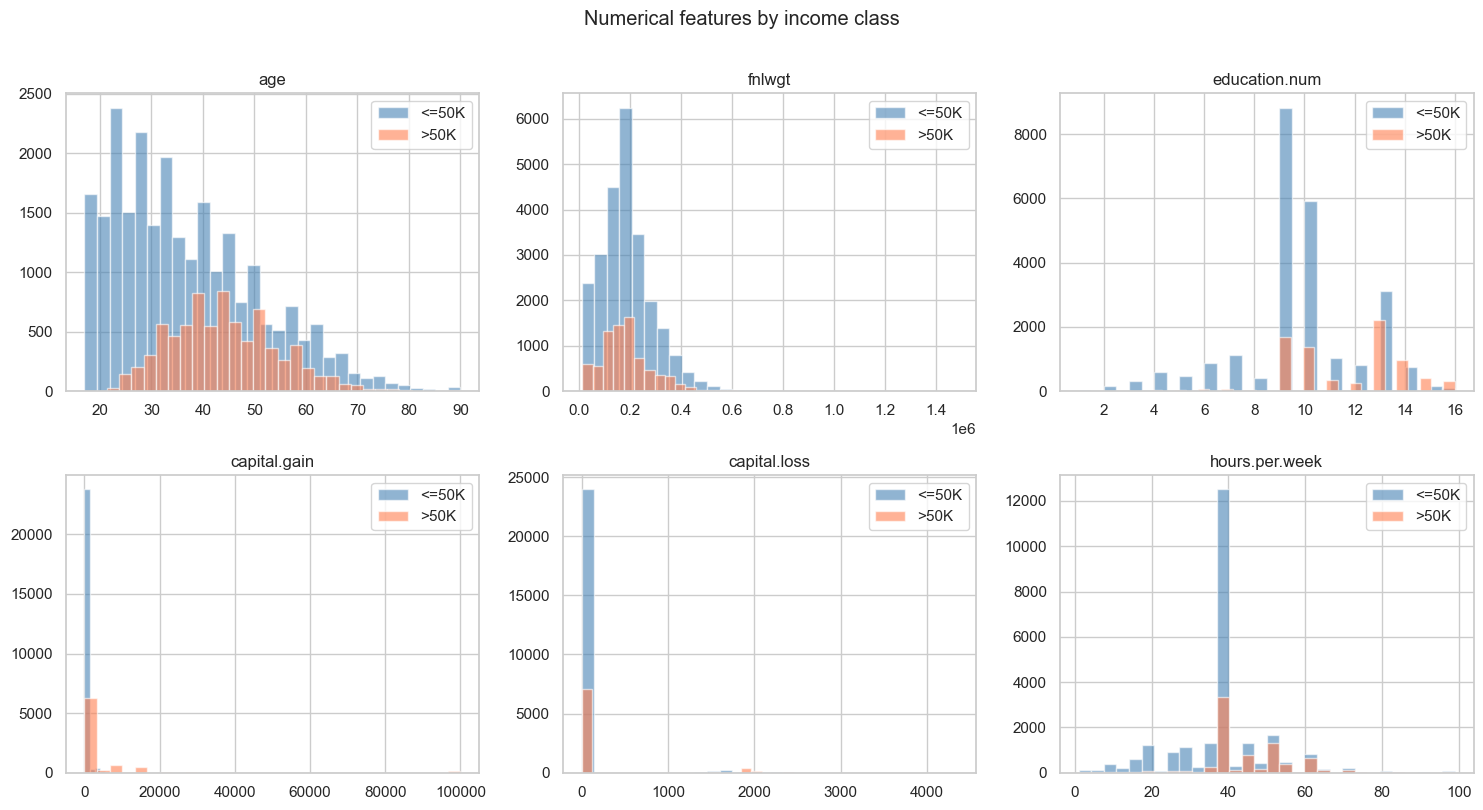

In [106]:
# Numerical features distributions by income class
num_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    for label, color in [("<=50K", "steelblue"), (">50K", "coral")]:
        ax.hist(df[df["income"] == label][col], bins=30, alpha=0.6, label=label, color=color)
    ax.set_title(col)
    ax.legend()
plt.suptitle("Numerical features by income class", y=1.01)
plt.tight_layout()
plt.show()

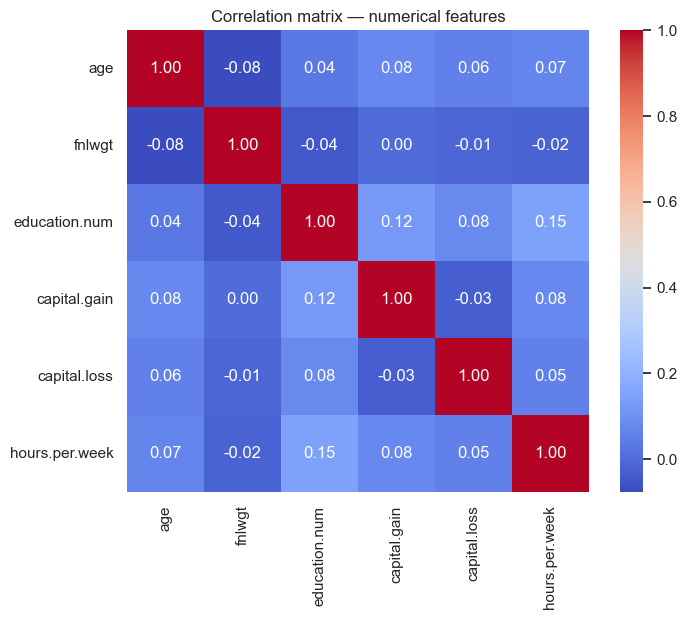

In [107]:
# Correlation heatmap (numerical features)
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix — numerical features")
plt.show()

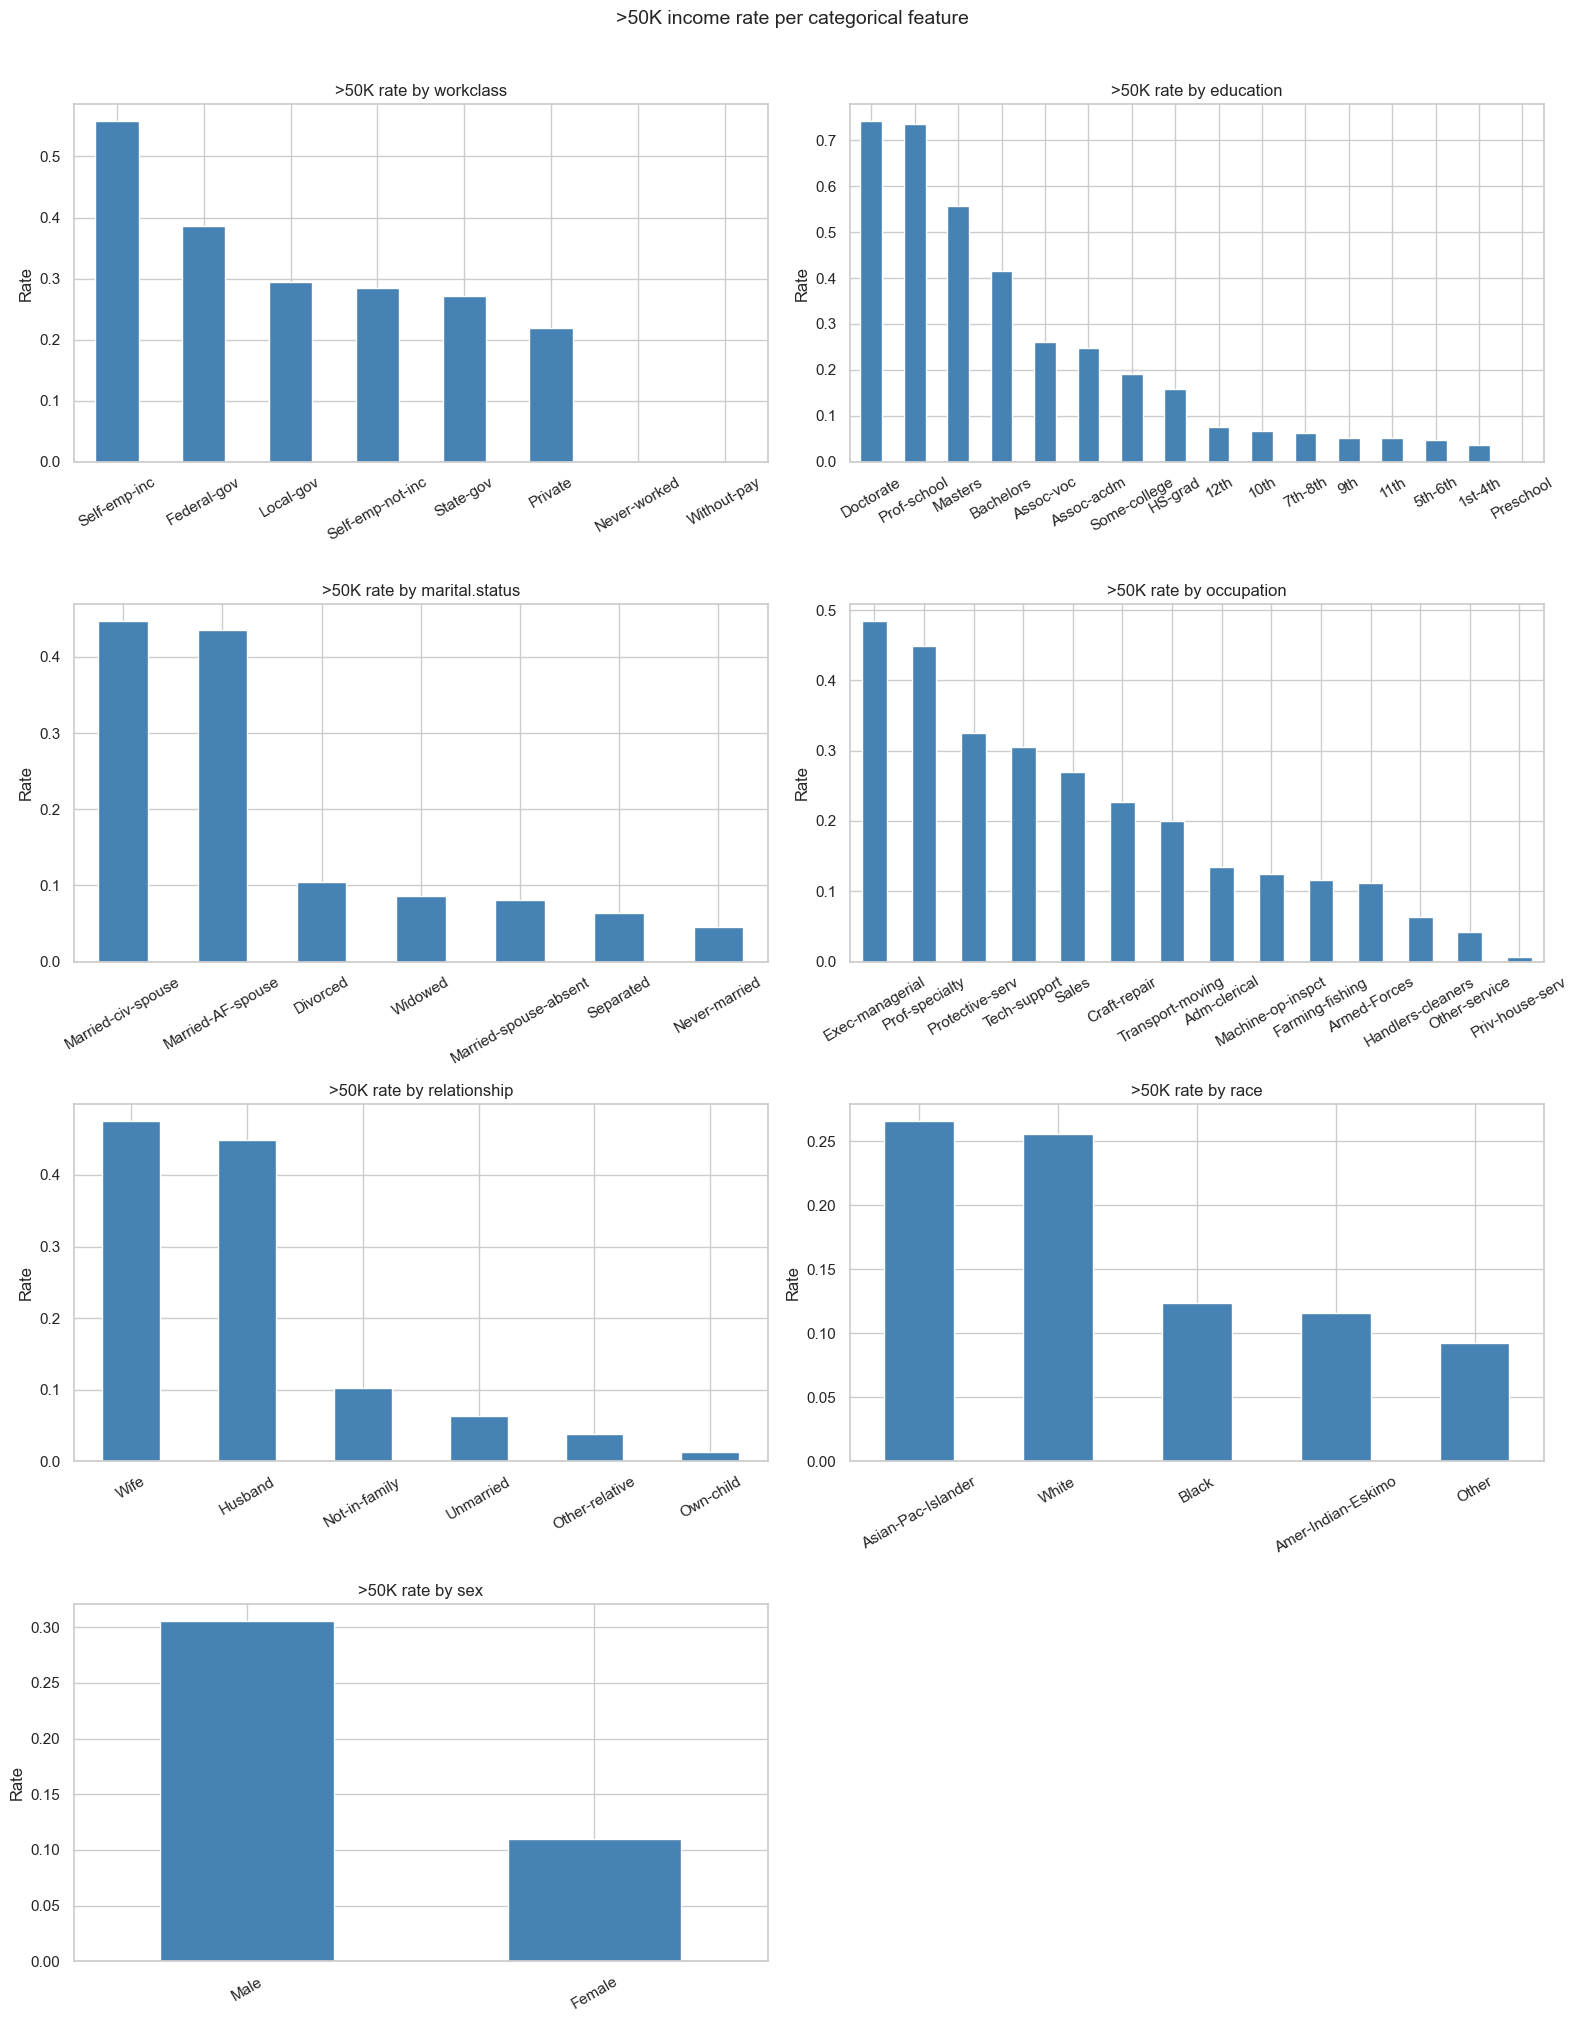

In [108]:
# Categorical features: >50K rate per category
cat_cols = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex"]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for ax, col in zip(axes.flatten(), cat_cols):
    rate = df.groupby(col)["income"].apply(lambda x: (x == ">50K").mean()).sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f">50K rate by {col}")
    ax.set_ylabel("Rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

axes.flatten()[-1].set_visible(False)  # hide empty subplot
plt.suptitle(">50K income rate per categorical feature", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

Preprocessing step


In [109]:
train = train.replace("?" , np.nan)
train = train.dropna()
train.shape

(30162, 15)

In [110]:
for col in cat_cols:
    print(train[col].value_counts())

workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64
education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          288
1st-4th          151
Preschool         45
Name: count, dtype: int64
marital.status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64
occupation
Prof-specialty       4038
Craft-repair         4030
Exec-managerial      3992
Adm-clerical         3721
Sales                3584
Other-servi

In [111]:
X = train.drop("income" , axis = 1)
y = train["income"]

X_train , X_test , y_train, y_test = train_test_split(X ,y , train_size = 0.8 , random_state = 42, stratify=y)


In [112]:
num_features = ["fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
age_feature = ["age"]

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

age_pipeline = Pipeline([
    ("log", FunctionTransformer(func=np.log1p, inverse_func=np.expm1)),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("ord_enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessing = ColumnTransformer([
    ("num_cols", num_pipeline, num_features),
    ("age",      age_pipeline, age_feature),
    ("cat_cols", cat_pipeline, cat_cols)
])

models = {
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
}

mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("salary_prediction")

results = []

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        full_pipeline = Pipeline([
            ("preprocessing", preprocessing),
            ("model", model)
        ])

        full_pipeline.fit(X_train, y_train)
        y_pred = full_pipeline.predict(X_test)
        y_prob = full_pipeline.predict_proba(X_test)[:, 1]

        # ── Metrics ──────────────────────────────────────────────────────────
        acc       = accuracy_score(y_test, y_pred)
        report    = classification_report(y_test, y_pred, output_dict=True)
        auc       = roc_auc_score((y_test == ">50K").astype(int), y_prob)
        precision = report[">50K"]["precision"]
        recall    = report[">50K"]["recall"]
        f1        = report[">50K"]["f1-score"]

        print(f"\n{'='*55}")
        print(f"  {name}")
        print(f"{'='*55}")
        print(f"  Accuracy  : {acc:.4f}")
        print(f"  Precision : {precision:.4f}")
        print(f"  Recall    : {recall:.4f}")
        print(f"  F1-score  : {f1:.4f}")
        print(f"  ROC-AUC   : {auc:.4f}")
        print()
        print(classification_report(y_test, y_pred))


        # ── MLflow logging ───────────────────────────────────────────────────
        mlflow.log_params(model.get_params())
        mlflow.log_metrics({
            "accuracy":  acc,
            "precision": precision,
            "recall":    recall,
            "f1_score":  f1,
            "roc_auc":   auc,
        })
        mlflow.sklearn.log_model(full_pipeline, artifact_path="model")

        results.append({"model": name, "accuracy": acc, "precision": precision,
                        "recall": recall, "f1_score": f1, "roc_auc": auc})

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame(results).set_index("model").sort_values("roc_auc", ascending=False)
print("\n── Model comparison ──")
print(summary.round(4).to_string())


2026/03/31 22:37:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 22:37:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  DecisionTree
  Accuracy  : 0.8132
  Precision : 0.6217
  Recall    : 0.6378
  F1-score  : 0.6296
  ROC-AUC   : 0.7546

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.88      4531
        >50K       0.62      0.64      0.63      1502

    accuracy                           0.81      6033
   macro avg       0.75      0.75      0.75      6033
weighted avg       0.81      0.81      0.81      6033



2026/03/31 22:37:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 22:37:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  LogisticRegression
  Accuracy  : 0.8324
  Precision : 0.7598
  Recall    : 0.4780
  F1-score  : 0.5868
  ROC-AUC   : 0.8678

              precision    recall  f1-score   support

       <=50K       0.85      0.95      0.89      4531
        >50K       0.76      0.48      0.59      1502

    accuracy                           0.83      6033
   macro avg       0.80      0.71      0.74      6033
weighted avg       0.82      0.83      0.82      6033



2026/03/31 22:37:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 22:37:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  RandomForest
  Accuracy  : 0.8619
  Precision : 0.7670
  Recall    : 0.6398
  F1-score  : 0.6976
  ROC-AUC   : 0.9131

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      4531
        >50K       0.77      0.64      0.70      1502

    accuracy                           0.86      6033
   macro avg       0.83      0.79      0.80      6033
weighted avg       0.86      0.86      0.86      6033



2026/03/31 22:37:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 22:37:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  GradientBoosting
  Accuracy  : 0.8667
  Precision : 0.8083
  Recall    : 0.6092
  F1-score  : 0.6948
  ROC-AUC   : 0.9271

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      4531
        >50K       0.81      0.61      0.69      1502

    accuracy                           0.87      6033
   macro avg       0.84      0.78      0.80      6033
weighted avg       0.86      0.87      0.86      6033


── Model comparison ──
                    accuracy  precision  recall  f1_score  roc_auc
model                                                             
GradientBoosting      0.8667     0.8083  0.6092    0.6948   0.9271
RandomForest          0.8619     0.7670  0.6398    0.6976   0.9131
LogisticRegression    0.8324     0.7598  0.4780    0.5868   0.8678
DecisionTree          0.8132     0.6217  0.6378    0.6296   0.7546
